<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on lab: Exploratory Data Analysis - Laptops Pricing dataset**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired throughout the module, to explore the effect of different features on the price of laptops. 


# Objectives

After completing this lab you will be able to:

 - Visualize individual feature patterns
 - Run descriptive statistical analysis on the dataset
 - Use groups and pivot tables to find the effect of categorical variables on price
 - Use Pearson Correlation to measure the interdependence between variables


# Setup


For this lab, we will be using the following libraries:

* `skillsnetwork` for downloading the data
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`scipy`](https://docs.scipy.org/doc/scipy/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for statistical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


# Install Required Libraries

You can install the required libraries by simply running the `pip install` command with a `%` sign before it. For this environment, `seaborn` library requires installation.


In [4]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [6]:
import numpy as np
import pandas as pd
from scipy import stats
%matplotlib inline

# Import the dataset

You should download the modified version of the data set from the last module. 
Run the following code block to download the CSV file to this environment.


The functions below will download the dataset into your browser:


In [16]:
filepath="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
df = pd.read_csv(filepath, header=None)

Print the first 5 entries of the dataset to confirm loading.


In [17]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,NaN,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
1,0.0,0,Acer,4,2,1,5,14.0,0.5517241379310345,8,256,3.5280000000000005,978,Low,0,1
2,1.0,1,Dell,3,1,1,3,15.600000000000001,0.6896551724137931,4,256,4.851000000000001,634,Low,1,0
3,2.0,2,Dell,3,1,1,7,15.600000000000001,0.9310344827586208,8,256,4.851000000000001,946,Low,1,0
4,3.0,3,Dell,4,2,1,5,13.299999999999999,0.5517241379310345,8,128,2.6901,1244,Low,0,1


# Task 1 - Visualize individual feature patterns

### Continuous valued features
Generate regression plots for each of the parameters "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price". Also, print the value of correlation of each feature with "Price".


In [18]:
headers = ["Index", "Unnamed: 0", "Manufacturer", "Category", "GPU", "OS", "CPU_core", 
           "Screen_Size_inch", "CPU_frequency", "RAM_GB", "Storage_GB_SSD", 
           "Weight_pounds", "Price", "CPU_rank", "GPU_rank", "Price_binned"]

df.columns = headers

In [22]:
# Convertimos las columnas necesarias a números
df['CPU_frequency'] = pd.to_numeric(df['CPU_frequency'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Eliminamos filas que hayan quedado con valores nulos para que el gráfico no falle
df.dropna(subset=['CPU_frequency', 'Price'], inplace=True)

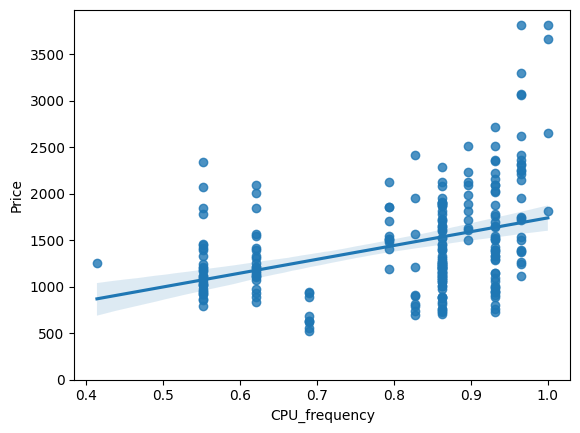

In [23]:
# Write your code below and press Shift+Enter to execute
# CPU_frequency plot
sns.regplot(x="CPU_frequency", y="Price", data=df)
plt.ylim(0,)
plt.show()


In [25]:
# Convertimos las columnas necesarias a números
df['Screen_Size_inch'] = pd.to_numeric(df['Screen_Size_inch'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Eliminamos filas que hayan quedado con valores nulos para que el gráfico no falle
df.dropna(subset=['Screen_Size_inch', 'Price'], inplace=True)

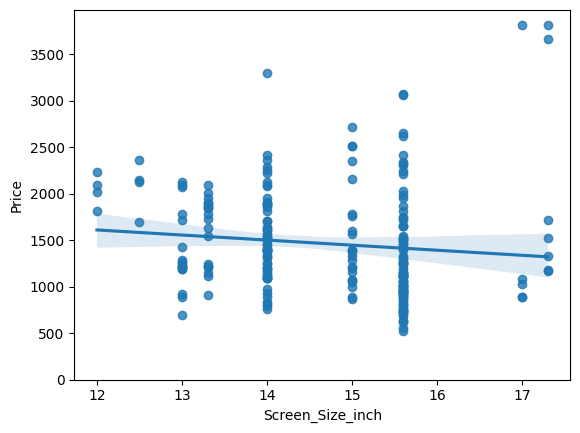

In [26]:
sns.regplot(x="Screen_Size_inch", y="Price", data=df)
plt.ylim(0,)
plt.show()

In [27]:
# Convertimos las columnas necesarias a números
df['Weight_pounds'] = pd.to_numeric(df['Weight_pounds'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Eliminamos filas que hayan quedado con valores nulos para que el gráfico no falle
df.dropna(subset=['Weight_pounds', 'Price'], inplace=True)

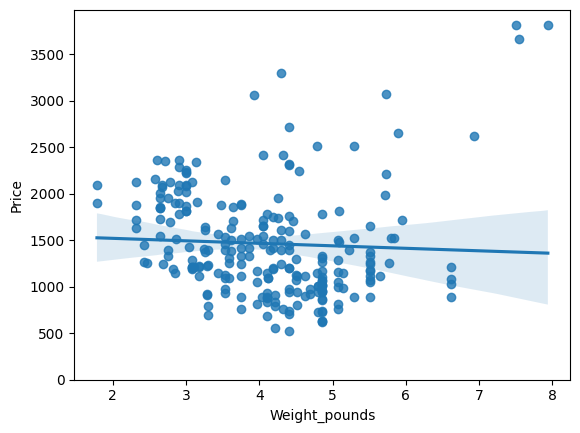

In [28]:
sns.regplot(x="Weight_pounds", y="Price", data=df)
plt.ylim(0,)
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="CPU_frequency", y="Price", data=df)
plt.ylim(0,)
```

</details>


<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="Screen_Size_inch", y="Price", data=df)
plt.ylim(0,)
```

</details>


<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="Weight_pounds", y="Price", data=df)
plt.ylim(0,)
```

</details>


In [29]:
# Correlation values of the three attributes with Price
for param in ['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds']:
    print(f"Correlation between {param} and Price: {df[param].corr(df['Price'])}")

Correlation between CPU_frequency and Price: 0.36666555892588604
Correlation between Screen_Size_inch and Price: -0.11064420817118273
Correlation between Weight_pounds and Price: -0.050312258377515476


<details>
    <summary>Click here for Solution</summary>

```python
for param in ["CPU_frequency", "Screen_Size_inch","Weight_pounds"]:
    print(f"Correlation of Price and {param} is ", df[[param,"Price"]].corr())
```

</details>


Interpretation: "CPU_frequency" has a 36% positive correlation with the price of the laptops. The other two parameters have weak correlation with price.


### Categorical features
Generate Box plots for the different feature that hold categorical values. These features would be "Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"


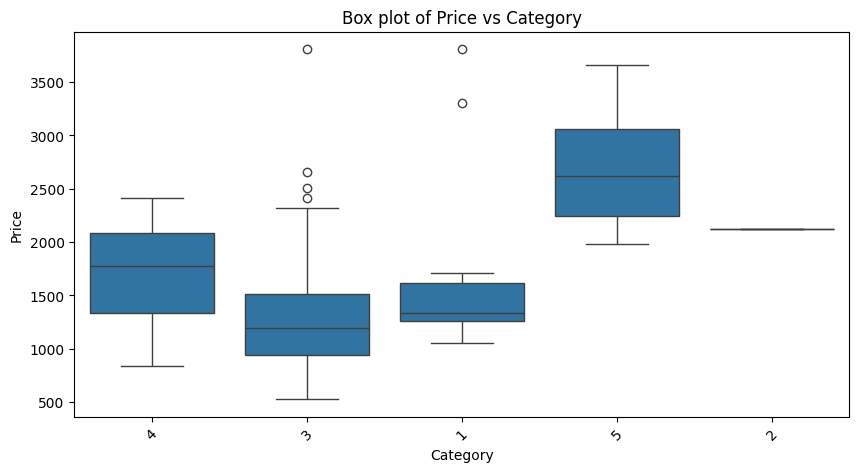

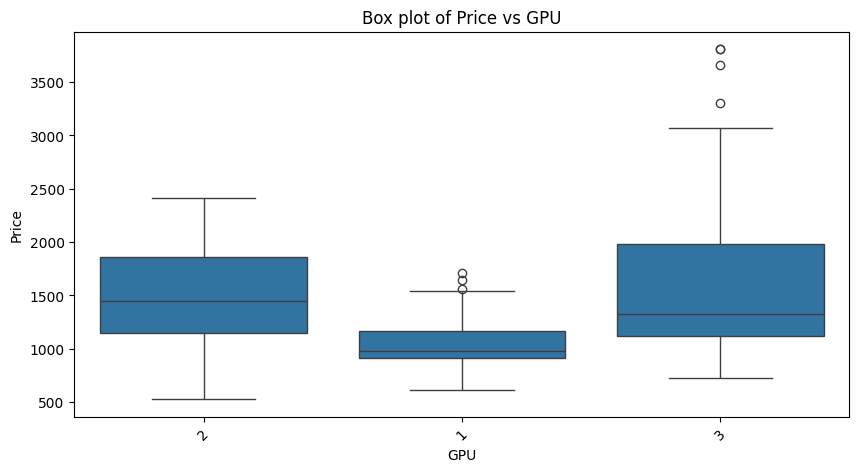

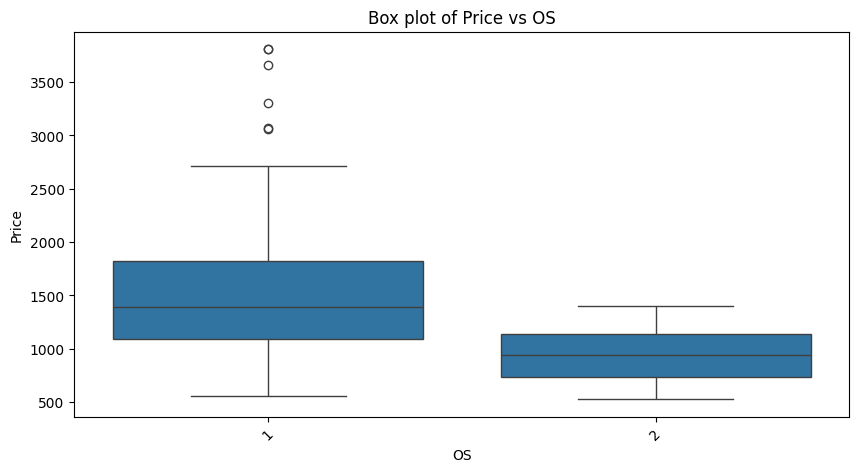

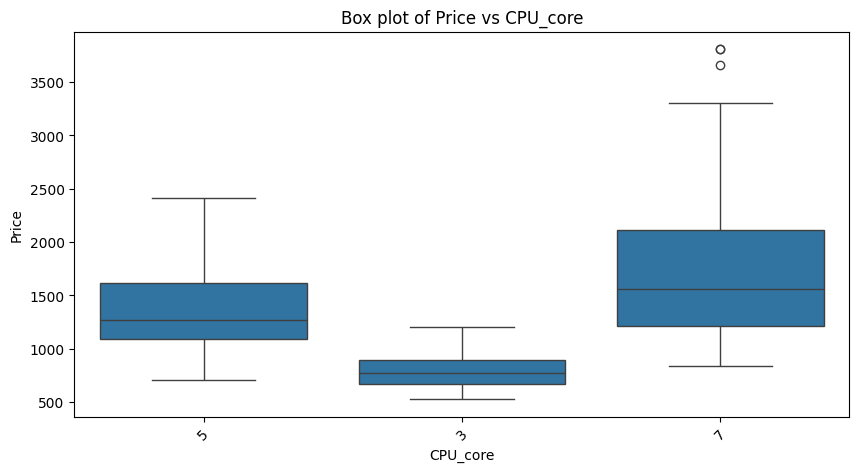

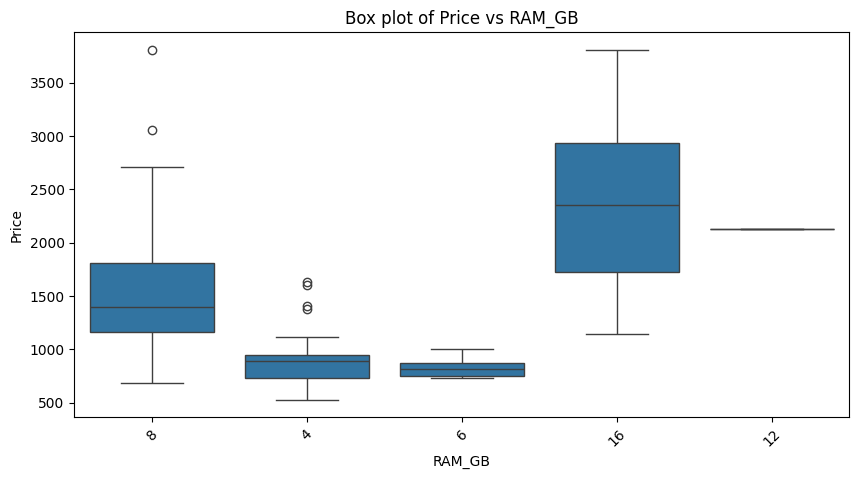

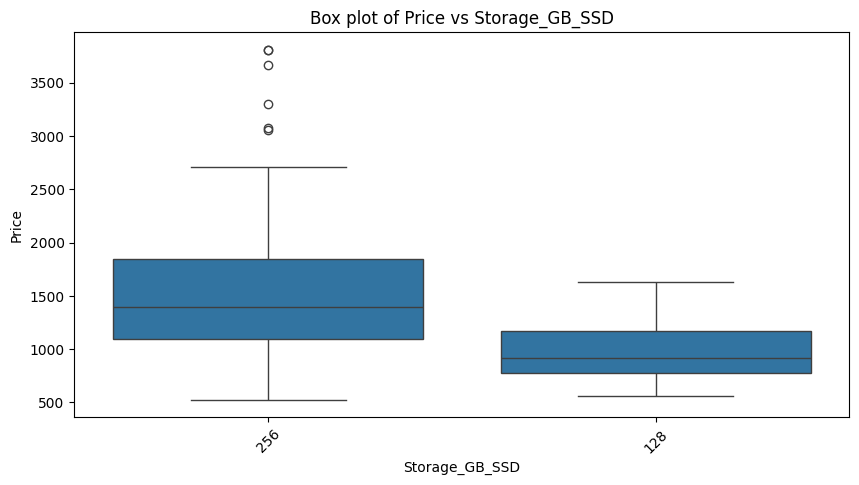

In [30]:
# Write your code below and press Shift+Enter to execute
# Category Box plot
columns = ['Category', 'GPU', 'OS', 'CPU_core', 'RAM_GB' ,'Storage_GB_SSD']
for col in columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y="Price", data=df)
    plt.title(f'Box plot of Price vs {col}')
    plt.xticks(rotation=45)
    plt.show()

<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="Category", y="Price", data=df)
```

</details>


# Task 2 - Descriptive Statistical Analysis


Generate the statistical description of all the features being used in the data set. Include "object" data types as well.


In [31]:
print(df.describe())
print(df.describe(include=['object']))

            Index  Screen_Size_inch  CPU_frequency  Weight_pounds        Price
count  238.000000        238.000000     238.000000     238.000000   238.000000
mean   118.500000         14.688655       0.813822       4.106221  1462.344538
std     68.848868          1.166045       0.141860       1.078442   574.607699
min      0.000000         12.000000       0.413793       1.786050   527.000000
25%     59.250000         14.000000       0.689655       3.246863  1066.500000
50%    118.500000         15.000000       0.862069       4.106221  1333.000000
75%    177.750000         15.600000       0.931034       4.851000  1777.000000
max    237.000000         17.300000       1.000000       7.938000  3810.000000
       Unnamed: 0 Manufacturer Category  GPU   OS CPU_core RAM_GB  \
count         238          238      238  238  238      238    238   
unique        238           11        5    3    2        3      5   
top             0         Dell        3    2    1        5      8   
freq         

<details>
<summary>Click here for Solution</summary>

```python
print(df.describe())
print(df.describe(include=['object']))
```

</details>


# Task 3 - GroupBy and Pivot Tables

Group the parameters "GPU", "CPU_core" and "Price" to make a pivot table and visualize this connection using the pcolor plot.


In [34]:
columns = ['GPU', 'CPU_core', 'Price']
df_gptest = df[columns].groupby(['GPU', 'CPU_core'], as_index=False).mean()
print(df_gptest)


  GPU CPU_core        Price
0   1        3   769.250000
1   1        5   998.500000
2   1        7  1167.941176
3   2        3   785.076923
4   2        5  1462.197674
5   2        7  1744.621622
6   3        3   784.000000
7   3        5  1220.680000
8   3        7  1945.097561


<details>
<summary>Click here for Solution</summary>

```python
df_gptest = df[['GPU','CPU_core','Price']]
grouped_test1 = df_gptest.groupby(['GPU','CPU_core'],as_index=False).mean()
print(grouped_test1)
```

</details>


In [35]:
grouped_pivot = df_gptest.pivot(index='GPU', columns='CPU_core')
print(grouped_pivot)

               Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561


<details>
<summary>Click here for Solution</summary>

```python
grouped_pivot = grouped_test1.pivot(index='GPU',columns='CPU_core')
print(grouped_pivot)
```

</details>


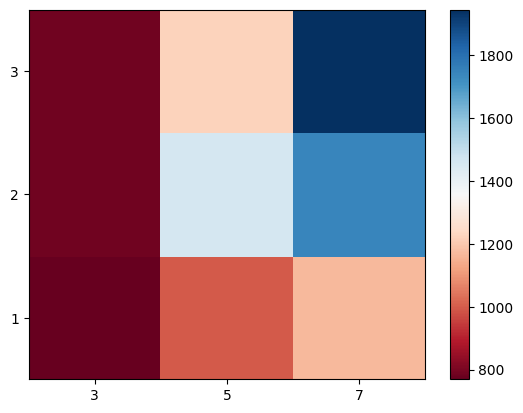

In [36]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

ax.set_xticklabels(row_labels, rotation=False)
ax.set_yticklabels(col_labels, rotation=False)

fig.colorbar(im)

<details>
<summary>Click here for Solution</summary>

```python
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

fig.colorbar(im)
```

</details>


# Task 4 - Pearson Correlation and p-values

Use the `scipy.stats.pearsonr()` function to evaluate the Pearson Coefficient and the p-values for each parameter tested above. This will help you determine the parameters most likely to have a strong effect on the price of the laptops.


In [37]:
df.columns

Index(['Index', 'Unnamed: 0', 'Manufacturer', 'Category', 'GPU', 'OS',
       'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB',
       'Storage_GB_SSD', 'Weight_pounds', 'Price', 'CPU_rank', 'GPU_rank',
       'Price_binned'],
      dtype='object')

In [39]:
#Use the `scipy.stats.pearsonr()` function to evaluate the Pearson Coefficient and the p-values for each parameter tested above. This will help you determine the parameters most likely to have a strong effect on the price of the laptops.

cols_to_fix = ['RAM_GB', 'CPU_frequency', 'Storage_GB_SSD', 'Screen_Size_inch', 
               'Weight_pounds', 'CPU_core', 'OS', 'GPU', 'Category', 'Price']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=cols_to_fix, inplace=True)

for param in ['RAM_GB', 'CPU_frequency', 'Storage_GB_SSD', 'Screen_Size_inch', 'Weight_pounds', 'CPU_core', 'OS', 'GPU', 'Category']:
    pearson_coef, p_value = stats.pearsonr(df[param], df['Price'])
    print(f"\nColumna: {param}")
    print(f"Pearson Correlation Coefficient: {pearson_coef}")
    print(f"P-value: {p_value}")



Columna: RAM_GB
Pearson Correlation Coefficient: 0.5492972971857844
P-value: 3.681560628842808e-20

Columna: CPU_frequency
Pearson Correlation Coefficient: 0.36666555892588604
P-value: 5.502463350713339e-09

Columna: Storage_GB_SSD
Pearson Correlation Coefficient: 0.243420755218103
P-value: 0.00014898923191724144

Columna: Screen_Size_inch
Pearson Correlation Coefficient: -0.11064420817118266
P-value: 0.0885339784683062

Columna: Weight_pounds
Pearson Correlation Coefficient: -0.05031225837751549
P-value: 0.43976938534338894

Columna: CPU_core
Pearson Correlation Coefficient: 0.4593977773355115
P-value: 7.912950127009359e-14

Columna: OS
Pearson Correlation Coefficient: -0.22172980114827384
P-value: 0.000569664255924674

Columna: GPU
Pearson Correlation Coefficient: 0.2882981988881427
P-value: 6.166949698364559e-06

Columna: Category
Pearson Correlation Coefficient: 0.28624275581264125
P-value: 7.225696235806605e-06


<details>
<summary>Click here for Solution</summary>

```python
for param in ['RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_inch','Weight_pounds','CPU_core','OS','GPU','Category']:
    pearson_coef, p_value = stats.pearsonr(df[param], df['Price'])
    print(param)
    print("The Pearson Correlation Coefficient for ",param," is", pearson_coef, " with a P-value of P =", p_value)
```

</details>


# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


Copyright © 2023 IBM Corporation. All rights reserved.


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-15|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-18|0.2|Vicky Kuo|Reviewed and Revised|--!>
